<a href="https://colab.research.google.com/github/isabelle-sauget/democracy-econ_growth_analysis/blob/main/variable_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

# PTR PASTRAREA CHINEI AM ELIMINAT INDICATORII:
# 'v2elintim_osp', 'v2elvotbuy_osp', 'v2elfrfair_osp',
# 'v2elaccept_osp', 'v2elasmoff_osp'
# deoarece China are partid unic si acesti indicatori nu au sens
# in cazul Chinei


# Citire date


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataframe_2024.csv")
print(df.head())

  country_name iso_code  year  v2elffelr_osp  v2psbars_osp  v2psoppaut_osp  \
0       Mexico      MEX  2024          2.979         3.541           2.835   
1     Suriname      SUR  2024          3.449         3.873           3.622   
2       Sweden      SWE  2024          3.947         3.960           3.899   
3  Switzerland      CHE  2024          3.870         3.947           3.888   
4        Ghana      GHA  2024          2.927         3.914           3.679   

   v2exrescon_osp  v2exbribe_osp  v2exembez_osp  v2lgotovst_osp  ...  \
0           1.726          1.448          2.257           1.015  ...   
1           3.141          2.697          3.366           2.359  ...   
2           3.202          3.948          3.957           3.688  ...   
3           3.677          3.846          3.913           3.250  ...   
4           2.352          1.032          1.262           3.075  ...   

   v2cacamps_osp  v2caviol_osp  v2caautmob_osp  v2capolit_osp  v2cacritic_osp  \
0          3.788 

## Varianta 1: sterg variabilele-problema, pastrez varietatea tarilor

#### Castig 23 de tari + Emiratele Arabe Unite daca sterg alegerile subnationale + autonomia partidelor de opozitie

In [ ]:
# sterg alegerile subnationale si castig 23 de tari
df1 = df.drop(columns='v2elffelr_osp')
# daca sterg 'v2psoppaut_osp', castig Emiratele Arabe Unite
df12 = df1.drop(columns='v2psoppaut_osp')

#dataset curatat
df12_clean = df12.dropna().copy()
print(df12_clean.isna().sum())
df1 = df12_clean.copy()
df1 = df1.drop(columns='v2lgqugen')
print(df1.shape)

country_name          0
iso_code              0
year                  0
v2psbars_osp          0
v2exrescon_osp        0
v2exbribe_osp         0
v2exembez_osp         0
v2lgotovst_osp        0
v2lgqugen             0
v2dlcountr_osp        0
v2juncind_osp         0
v2juhcind_osp         0
v2jucorrdc_osp        0
v2jucomp_osp          0
v2clrspct_osp         0
v2clacjstw_osp        0
v2pepwrgen_osp        0
v2stcritrecadm_osp    0
v2cseeorgs_osp        0
v2csantimv_osp        0
v2csrlgcon_osp        0
v2mecenefi_osp        0
v2mebias_osp          0
v2mecorrpt_osp        0
v2pepwrort_osp        0
v2pepwrses_osp        0
v2pehealth_osp        0
v2cacamps_osp         0
v2caviol_osp          0
v2caautmob_osp        0
v2capolit_osp         0
v2cacritic_osp        0
v2smgovcapsec_osp     0
v2smpardom_osp        0
v2smfordom_osp        0
v2smpolsoc_osp        0
GDPPC                 0
dtype: int64
(160, 36)



## Varianta 2: sterg tari, pastrez varietatea variabilelor

#### Pastrez variabila alegerilor locale

In [ ]:
# pastrez Alegerile Locale, importante dpdv teoretic si sustinuta ca determinant
# al cresterii din lit. de specialitate, insa pierd 23 de tari, inclusiv o economie
# mare precum Singapore
#ar fi fost util sa mai includ in dataset indicatori ai democratiei locale
#precum Regional offices relative power (C) (v2elrgpwr)

#keep in mind, am pierdut cateva variabile din cauza Chinei
df2 = df.dropna().copy()


In [ ]:
print(df2.isna().sum())
print(df1.shape)
print(df2.shape)

country_name          0
iso_code              0
year                  0
v2elffelr_osp         0
v2psbars_osp          0
v2psoppaut_osp        0
v2exrescon_osp        0
v2exbribe_osp         0
v2exembez_osp         0
v2lgotovst_osp        0
v2lgqugen             0
v2dlcountr_osp        0
v2juncind_osp         0
v2juhcind_osp         0
v2jucorrdc_osp        0
v2jucomp_osp          0
v2clrspct_osp         0
v2clacjstw_osp        0
v2pepwrgen_osp        0
v2stcritrecadm_osp    0
v2cseeorgs_osp        0
v2csantimv_osp        0
v2csrlgcon_osp        0
v2mecenefi_osp        0
v2mebias_osp          0
v2mecorrpt_osp        0
v2pepwrort_osp        0
v2pepwrses_osp        0
v2pehealth_osp        0
v2cacamps_osp         0
v2caviol_osp          0
v2caautmob_osp        0
v2capolit_osp         0
v2cacritic_osp        0
v2smgovcapsec_osp     0
v2smpardom_osp        0
v2smfordom_osp        0
v2smpolsoc_osp        0
GDPPC                 0
dtype: int64
(160, 36)
(137, 39)


# Heatmaps


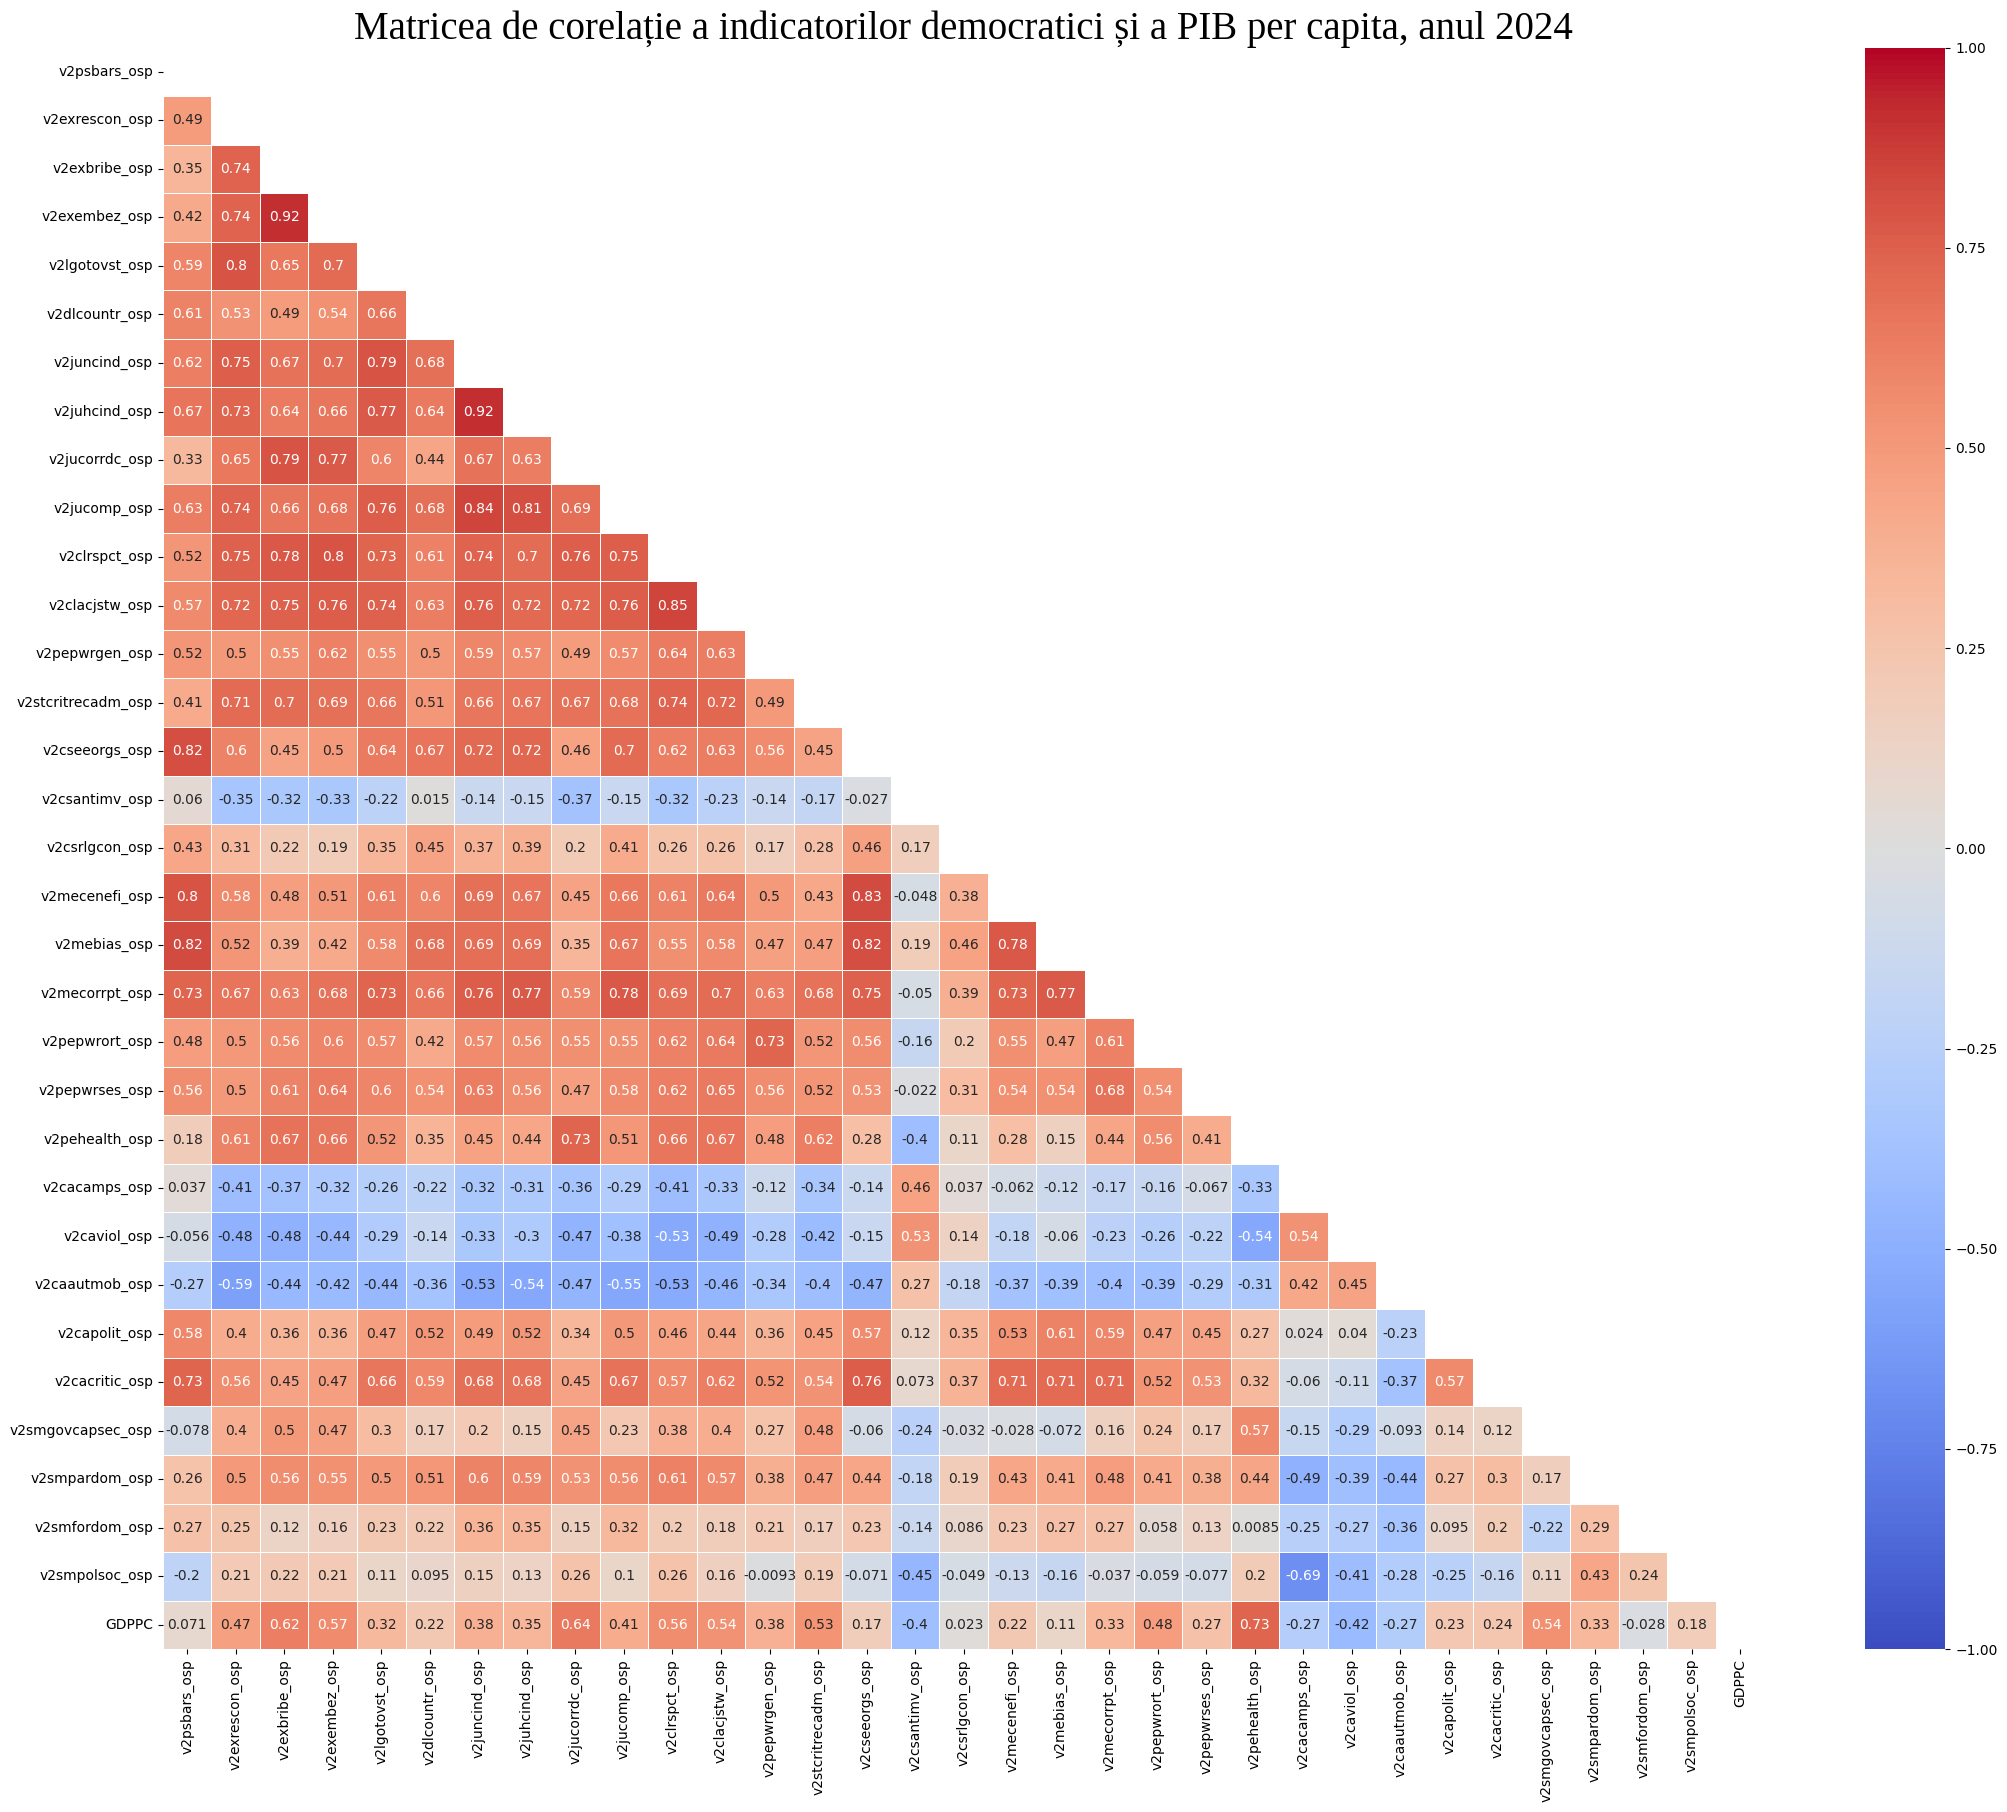

In [ ]:
#strategia 1
col_literale = ['country_name','iso_code','year']
col_num = [col for col in df1.columns if col not in col_literale]

matrice_cor1 = df1[col_num].corr()
plt.figure(figsize=(22,18))
mask = np.triu(np.ones_like(matrice_cor1, dtype=bool))

sns.heatmap(matrice_cor1,
            mask=mask,
            cmap='coolwarm',
            annot=True,
            square=True,
            linewidths=.5,
            vmin=-1, vmax=1)

plt.title("Matricea de corelație a indicatorilor democratici și a PIB per capita, anul 2024", fontsize=28, fontname="Liberation Serif")
plt.tight_layout()
plt.show()


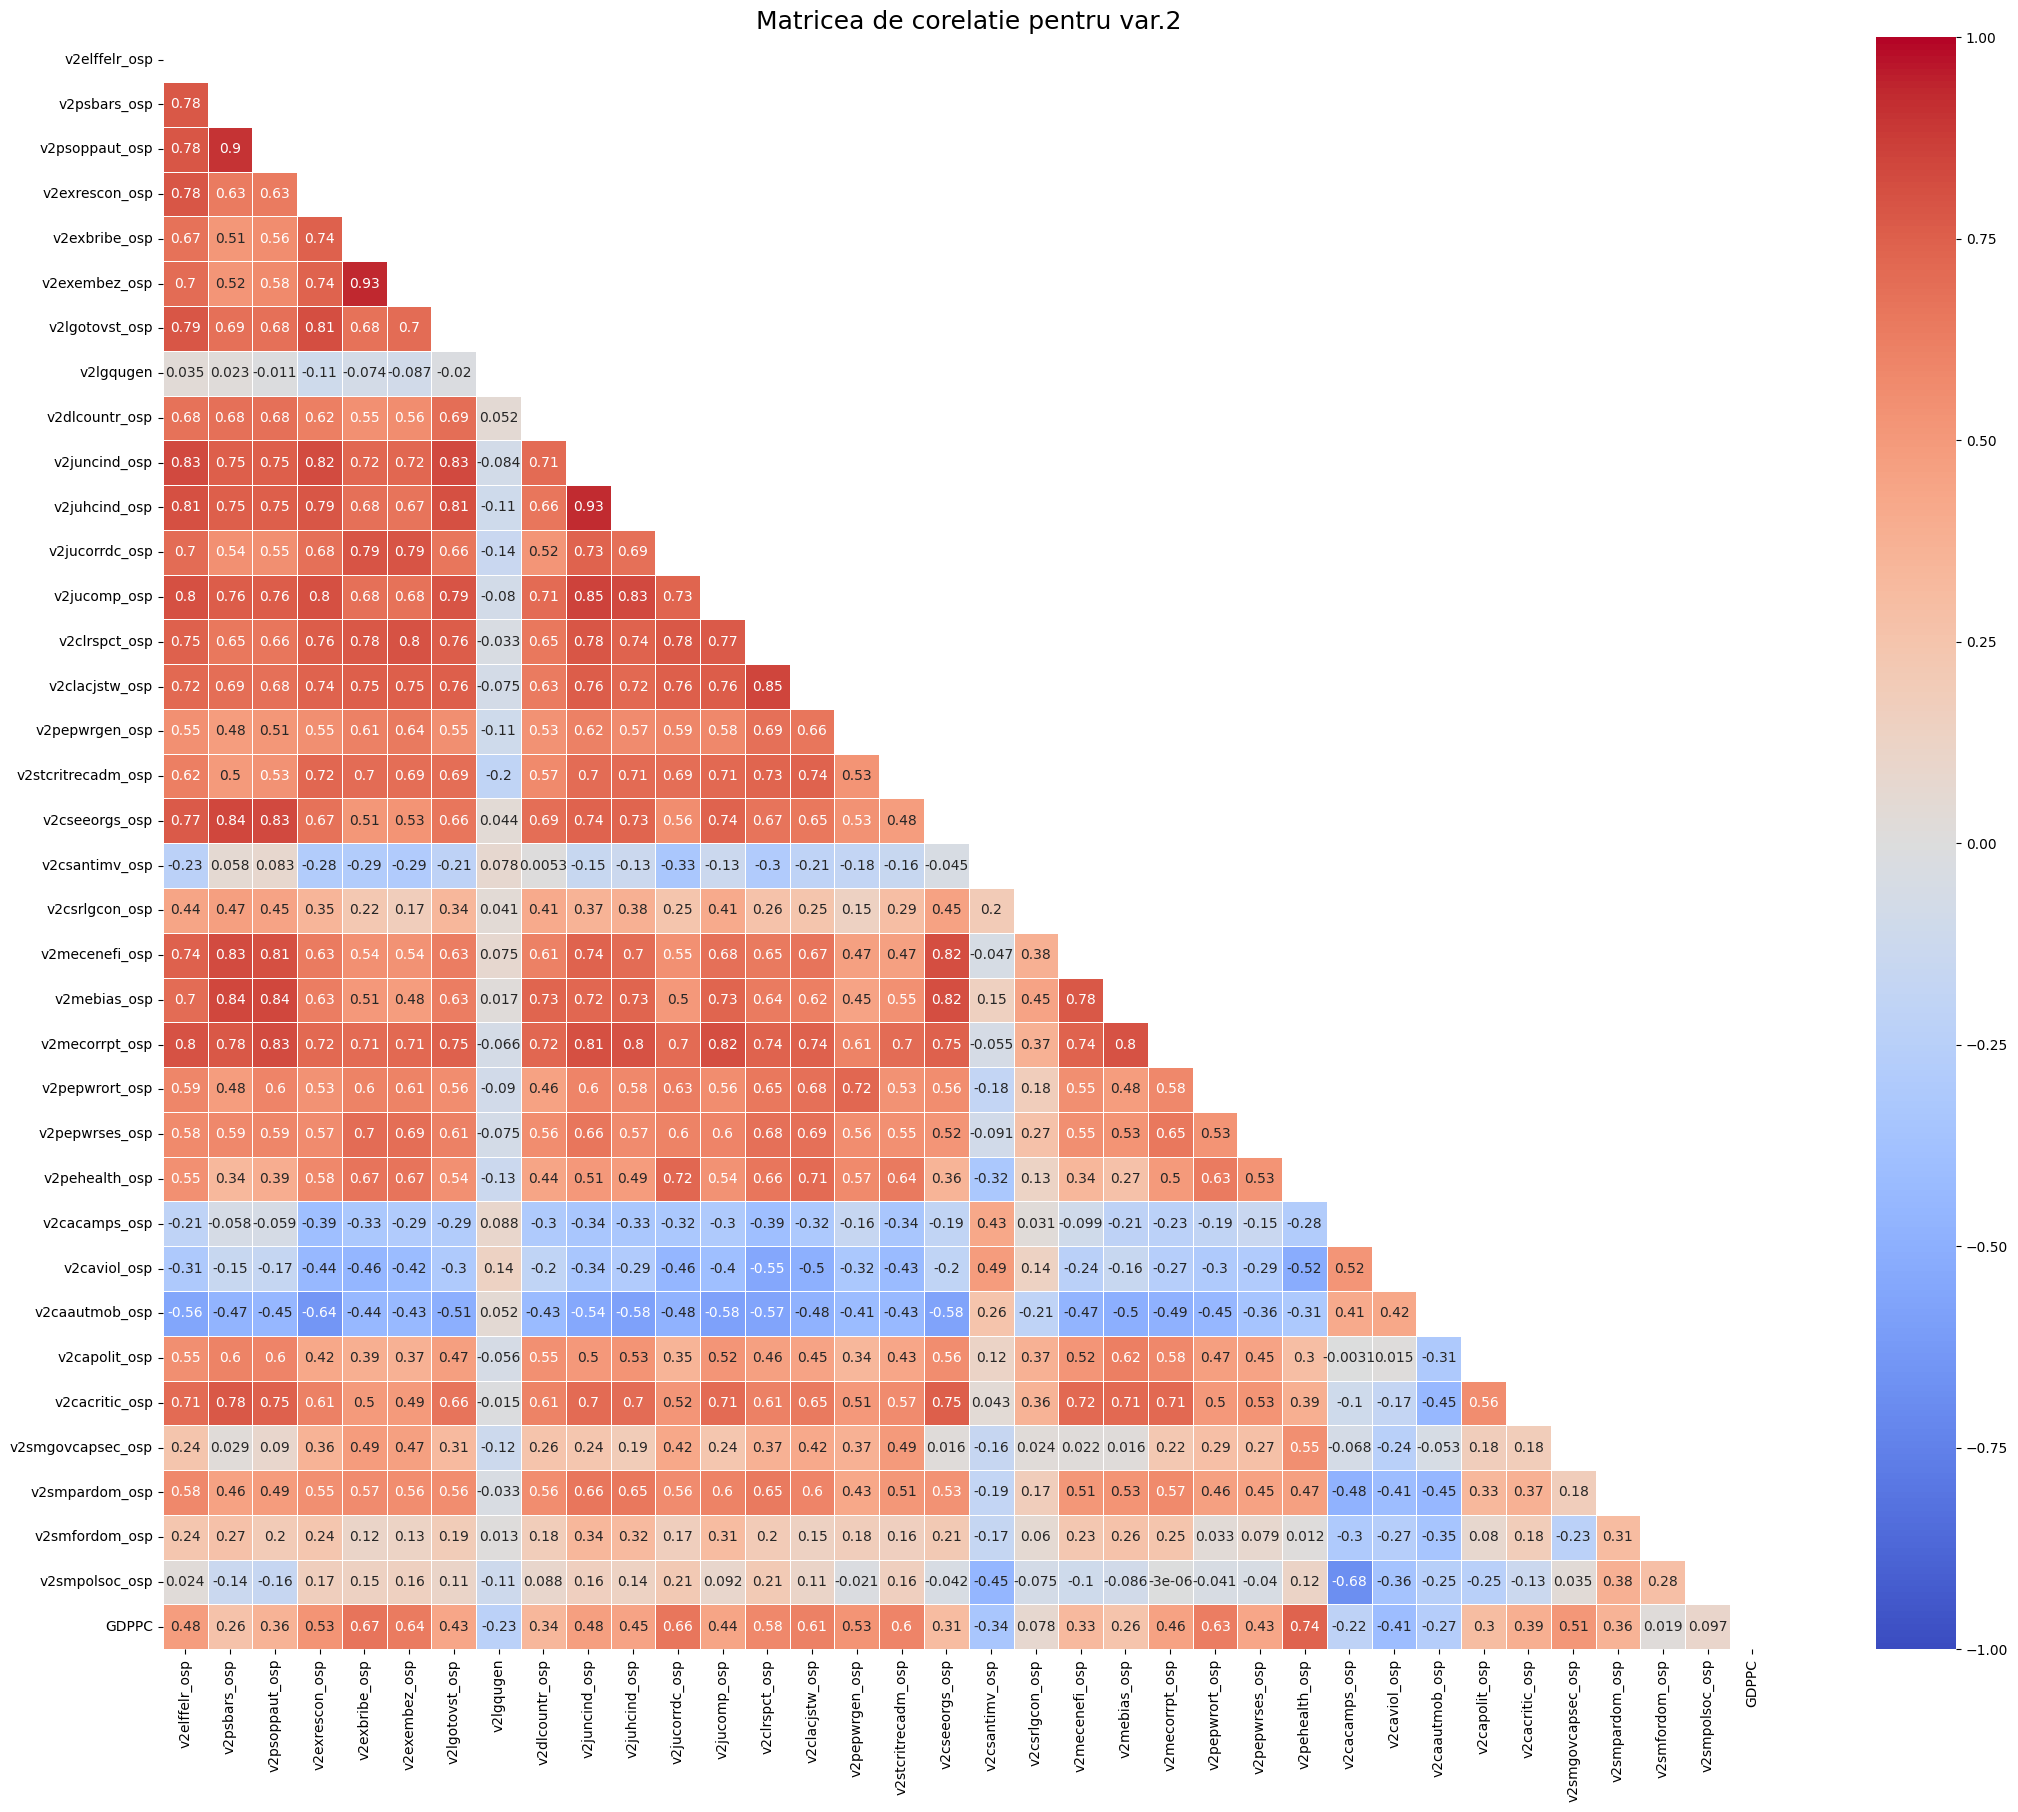

In [ ]:
col_literale = ['country_name','iso_code','year']
col_num = [col for col in df2.columns if col not in col_literale]

matrice_cor2 = df2[col_num].corr()
plt.figure(figsize=(22,18))
mask = np.triu(np.ones_like(matrice_cor2, dtype=bool))

sns.heatmap(matrice_cor2,
            mask=mask,
            cmap='coolwarm',
            annot=True,
            square=True,
            linewidths=.5,
            vmin=-1, vmax=1)

plt.title("Matricea de corelatie pentru var.2", fontsize=18)
plt.tight_layout()
plt.show()

### Aleg sa continui mai departe cu df1, care include EAU, Qatar, Singapore si Croatia

# Multicoliniaritate


In [ ]:
# selectez variabilele numerice INAFARA de PIB

In [ ]:
var_factori = [col for col in df1.columns if col not in ['country_name','iso_code','year','GDPPC']]
matrice_cor1 = df1[var_factori].corr().abs()
upper = matrice_cor1.where(np.triu(np.ones(matrice_cor1.shape), k=1).astype(bool))

prag = 0.9
variabile_de_sters = [column for column in upper.columns if any(upper[column] > prag)]

print(f"Exista {len(variabile_de_sters)} variabile redundante:")
print(variabile_de_sters)


Exista 2 variabile redundante:
['v2exembez_osp', 'v2juhcind_osp']


In [ ]:
df_fa = df1.drop(columns=['v2exembez_osp','v2juncind_osp'])
print(df_fa.shape)

(160, 34)


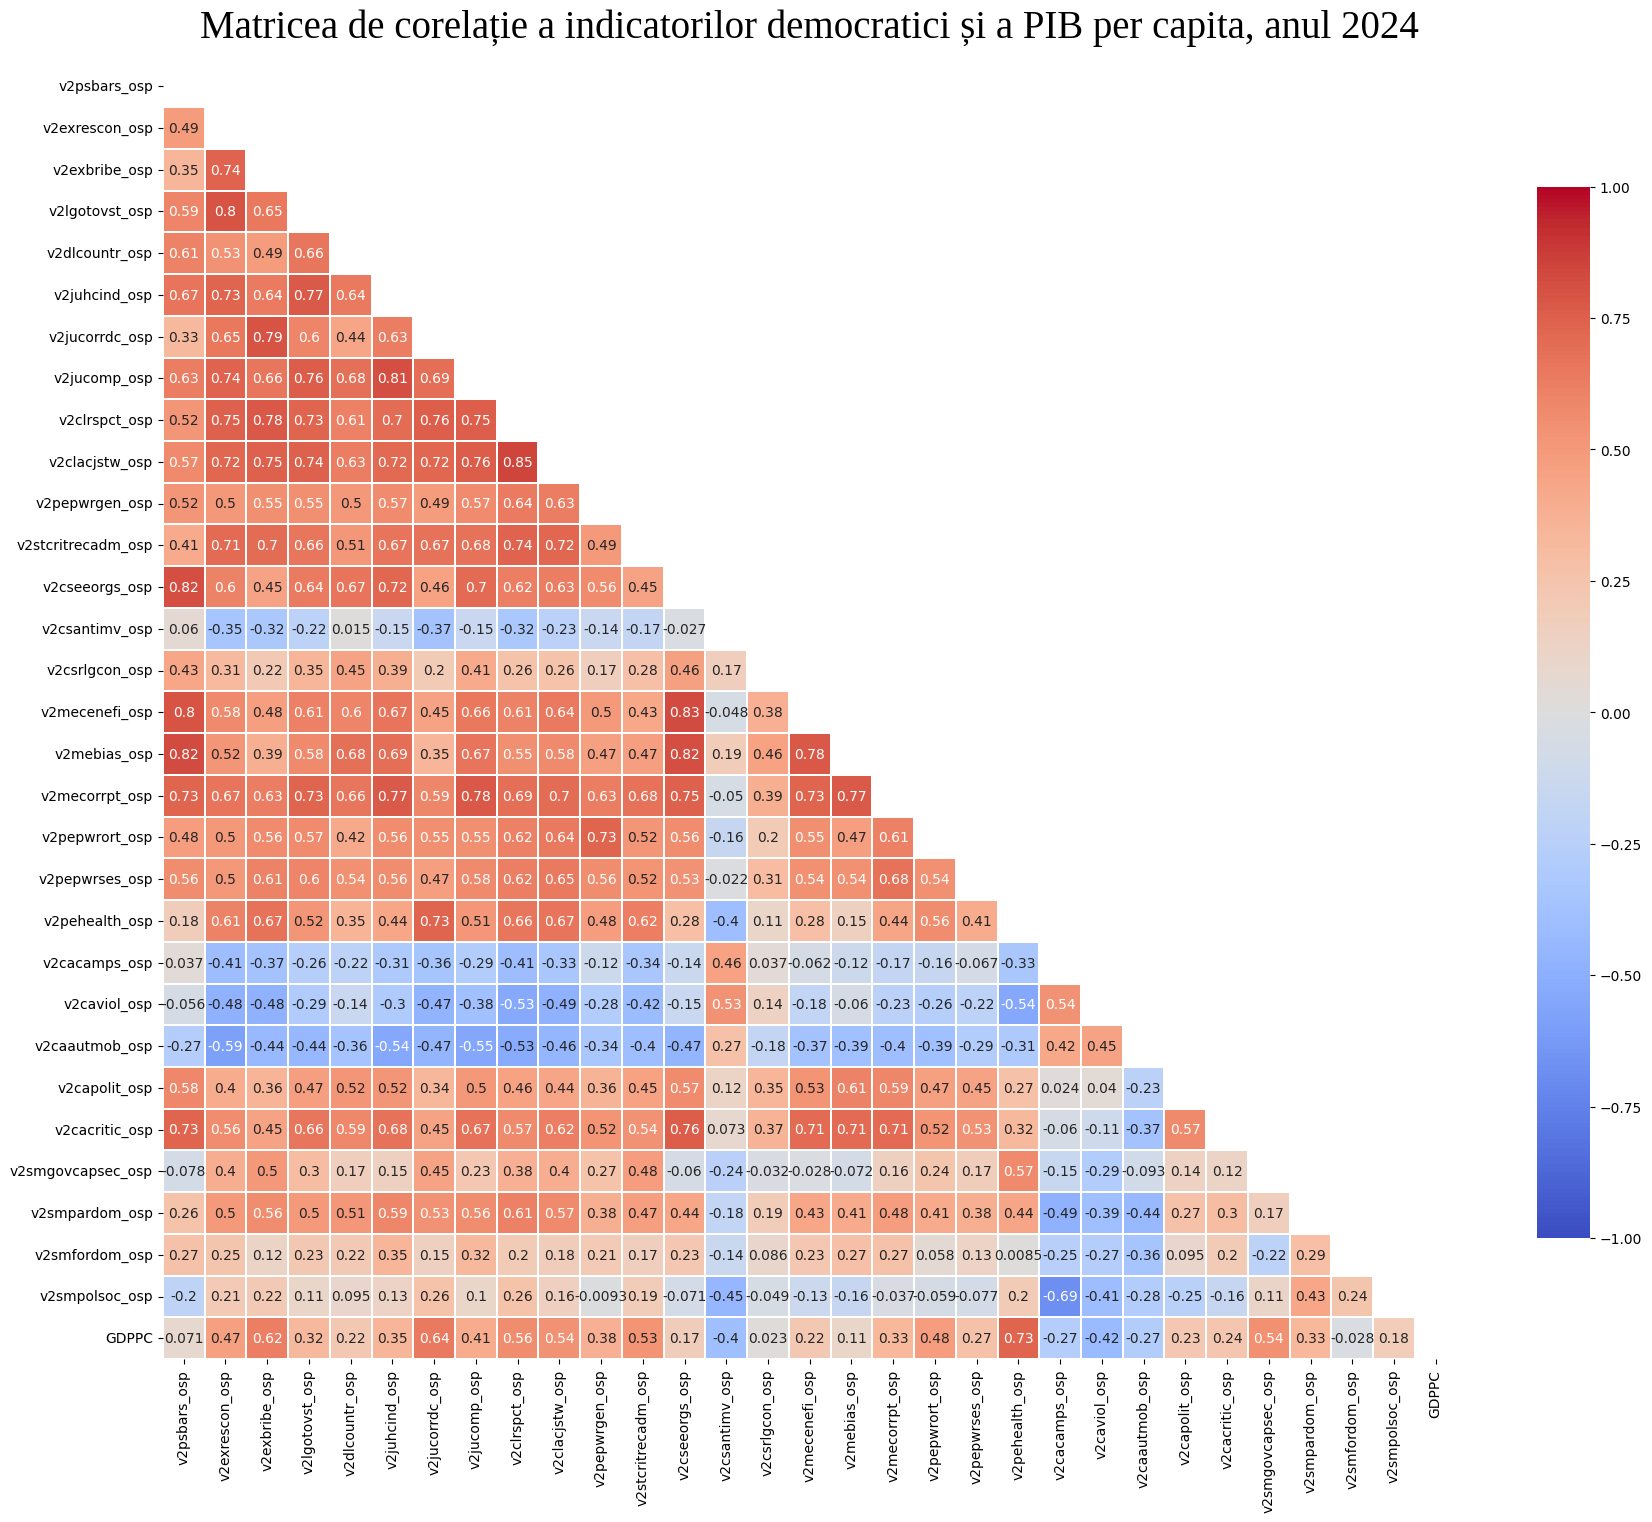

In [ ]:
col_num_fa = [col for col in df_fa.columns if col not in col_literale]

matrice_cor = df_fa[col_num_fa].corr()
plt.figure(figsize=(18,18))
mask = np.triu(np.ones_like(matrice_cor, dtype=bool))

sns.heatmap(matrice_cor,
            mask=mask,
            cmap='coolwarm',
            annot=True,
            square=True,
            linewidths=.2,
            vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.6})

plt.title("Matricea de corelație a indicatorilor democratici și a PIB per capita, anul 2024",pad=20, fontsize=28, fontname="Liberation Serif")
plt.tight_layout()
plt.savefig("heatmap.png",dpi=300, bbox_inches='tight')
plt.show()

## Script pentru selectarea a ce variabile pastrez dintre cele corelate

In [ ]:
# prag_corelatie = 0.6
# var_factori = [col for col in df1.columns if col not in ['country_name','iso_code','year','GDPPC']]
# matrice_cor = df1[var_factori].corr().abs()

# # gasirea perechilor unice care depasesc pragul de corelatie
# perechi_corelate = []
# for i in range(len(matrice_cor.columns)):
#     for j in range(i + 1, len(matrice_cor.columns)): # i+1 ca să luam doar triunghiul superior
#         valoare_corelatie = matrice_cor.iloc[i, j]
#         if valoare_corelatie > prag_corelatie:
#             var1 = matrice_cor.columns[i]
#             var2 = matrice_cor.columns[j]
#             perechi_corelate.append((var1, var2, valoare_corelatie))

# print(f"Exista {len(perechi_corelate)} perechi de variabile cu o corelatie > {prag_corelatie}.\n")

# # iterarea prin perechi si cererea inputului
# variabile_de_sters = set()

# for var1, var2, corelatie in perechi_corelate:
#     # se trece peste daca acea variabila a fost deja stearsa
#     if var1 in variabile_de_sters or var2 in variabile_de_sters:
#         continue

#     print(f"Corelatia: {corelatie:.3f}")
#     print(f"[0] {var1}")
#     print(f"[1] {var2}")

#     # bucla de validare
#     while True:
#         alegere = input(f"Tasteaza 0 pentru a o sterge pe prima, 1 pentru a doua, iar s pentru a trece peste la urmatoare pereche").strip().lower()

#         if alegere == '0':
#             variabile_de_sters.add(var1)
#             print(f"Spre stergere -> {var1}")
#             break
#         elif alegere == '1':
#             variabile_de_sters.add(var2)
#             print(f"Spre stergere -> {var2}")
#             break
#         elif alegere == 's':
#             print("Se pastreaza amandoua. Treci mai departe")
#             break
#         else:
#             print("Input invalid. Tasteaza 0, 1 sau s.")

# # 6. Cream setul final de date, fără variabilele alese pentru ștergere
# df_pca2 = df1.drop(columns=list(variabile_de_sters))
# print("Curatarea a fost terminata")
# print(f"Au fost sterse in total {len(variabile_de_sters)} variabile manual.")
# print(f"Setul de date este gata pentru PCA si are {df_pca2.shape[1]} coloane.")

# Testele KMO si Bartlett pentru sfericitate

In [ ]:
!pip install factor_analyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

X = df_fa[col_num_fa].copy()
# Valoarea testului trebuie sa fie aproape de 1
kmo_per_variable, kmo_total = calculate_kmo(X)
print(f"Scorul Kaiser-Meyer-Olkin : {kmo_total:.3f}")

chi_square_value, p_value = calculate_bartlett_sphericity(X)
# P-value al testului Bartlett
# H0: variabile ortogonale
# H1: exista cel putin 1 factor comun
print(f"\nTestul Bartlett (p-value): {p_value:.5e}\n")

Scorul Kaiser-Meyer-Olkin : 0.934

Testul Bartlett (p-value): 0.00000e+00



/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [ ]:
print(df_fa.columns)

Index(['country_name', 'iso_code', 'year', 'v2psbars_osp', 'v2exrescon_osp',
       'v2exbribe_osp', 'v2lgotovst_osp', 'v2dlcountr_osp', 'v2juhcind_osp',
       'v2jucorrdc_osp', 'v2jucomp_osp', 'v2clrspct_osp', 'v2clacjstw_osp',
       'v2pepwrgen_osp', 'v2stcritrecadm_osp', 'v2cseeorgs_osp',
       'v2csantimv_osp', 'v2csrlgcon_osp', 'v2mecenefi_osp', 'v2mebias_osp',
       'v2mecorrpt_osp', 'v2pepwrort_osp', 'v2pepwrses_osp', 'v2pehealth_osp',
       'v2cacamps_osp', 'v2caviol_osp', 'v2caautmob_osp', 'v2capolit_osp',
       'v2cacritic_osp', 'v2smgovcapsec_osp', 'v2smpardom_osp',
       'v2smfordom_osp', 'v2smpolsoc_osp', 'GDPPC'],
      dtype='object')


# Creare fisier gata pentru analiza factoriala


In [ ]:
cale_fisier = "/content/drive/MyDrive/Colab Notebooks/FA.csv"
df_fa.to_csv(cale_fisier, index=False)